# 02. Análisis Exploratorio de Datos (EDA)

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
#Lectura de datos e impresión de las primeras filas
url_hr = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/employee_attrition/HR-Employee-Attrition-All.csv"
df_hr = pd.read_csv(url_hr)
print(df_hr.head())

In [ ]:
# Guardar el DataFrame en un archivo CSV con validación de la ruta
RUTA_CSV = os.path.join("..", "data", "HR-Employee-Attrition.csv")
if not os.path.exists(os.path.dirname(RUTA_CSV)):
    os.makedirs(os.path.dirname(RUTA_CSV))
    
df_hr.to_csv(RUTA_CSV, index=False)

In [ ]:
df_hr.head()

## 2.1 Revisión de valores faltantes:

In [27]:
# Revisión de valores faltantes
valores_faltantes = df_hr.isnull().sum()
porcentaje_faltantes = (valores_faltantes / len(df_hr)) * 100

resumen_faltantes = pd.DataFrame({
    "valores_faltantes": valores_faltantes,
    "porcentaje (%)": porcentaje_faltantes.round(2)
})
resumen_faltantes = resumen_faltantes[resumen_faltantes["valores_faltantes"] > 0]

if resumen_faltantes.empty:
    print("No se encontraron valores faltantes en ninguna columna.")
else:
    print("Columnas con valores faltantes:")
    print(resumen_faltantes.sort_values("porcentaje (%)", ascending=False))

No se encontraron valores faltantes en ninguna columna.


In [26]:
# Columnas con un unico valor (constantes): no aportan informacion para
# distinguir entre clases, por lo que se descartaran en el preprocesamiento.
columnas_constantes = [c for c in df_hr.columns if df_hr[c].nunique() == 1]
print("Columnas constantes encontradas:", columnas_constantes)
for c in columnas_constantes:
    print(f"  {c}: unico valor = {df_hr[c].unique()}")

Columnas constantes encontradas: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: unico valor = [1]
  Over18: unico valor = ['Y']
  StandardHours: unico valor = [80]


## 2.2 Detección de valores atípicos:

In [ ]:
# Detección de valores atípicos.
# Estadisticas descriptivas de variables numericas
numeric_cols = df_hr.select_dtypes(include="number").columns.tolist()
print(f"Variables numericas disponibles: {numeric_cols}")
print(len(numeric_cols))
df_hr[numeric_cols].describe().round(2)

In [ ]:
# Método estadístico 1: IQR (rango intercuartílico)
resumen_outliers_iqr = []
for col in numeric_cols:
    q1 = df_hr[col].quantile(0.25)
    q3 = df_hr[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df_hr[(df_hr[col] < limite_inferior) | (df_hr[col] > limite_superior)]
    resumen_outliers_iqr.append({
        "columna": col,
        "outliers_iqr": len(outliers),
        "porcentaje (%)": round(100 * len(outliers) / len(df_hr), 2)
    })
    
resumen_outliers_iqr = pd.DataFrame(resumen_outliers_iqr).sort_values(
    "outliers_iqr", ascending=False
)
print("Outliers detectados por IQR:")
print(resumen_outliers_iqr[resumen_outliers_iqr["outliers_iqr"] > 0])

Outliers detectados por IQR:
                    columna  outliers_iqr  porcentaje (%)
20    TrainingTimesLastYear           238           16.19
15        PerformanceRating           226           15.37
11            MonthlyIncome           114            7.76
24  YearsSinceLastPromotion           107            7.28
22           YearsAtCompany           104            7.07
18         StockOptionLevel            85            5.78
19        TotalWorkingYears            63            4.29
13       NumCompaniesWorked            52            3.54
23       YearsInCurrentRole            21            1.43
25     YearsWithCurrManager            14            0.95


In [ ]:
# Método estadístico 2: Z-score
z_scores = (df_hr[numeric_cols] - df_hr[numeric_cols].mean()) / df_hr[numeric_cols].std()
outliers_zscore = (z_scores.abs() > 3).sum()
print("\nOutliers detectados por Z-score (|z| > 3):")
print(outliers_zscore[outliers_zscore > 0])


Outliers detectados por Z-score (|z| > 3):
TotalWorkingYears          16
YearsAtCompany             25
YearsInCurrentRole         13
YearsSinceLastPromotion    42
YearsWithCurrManager       14
dtype: int64


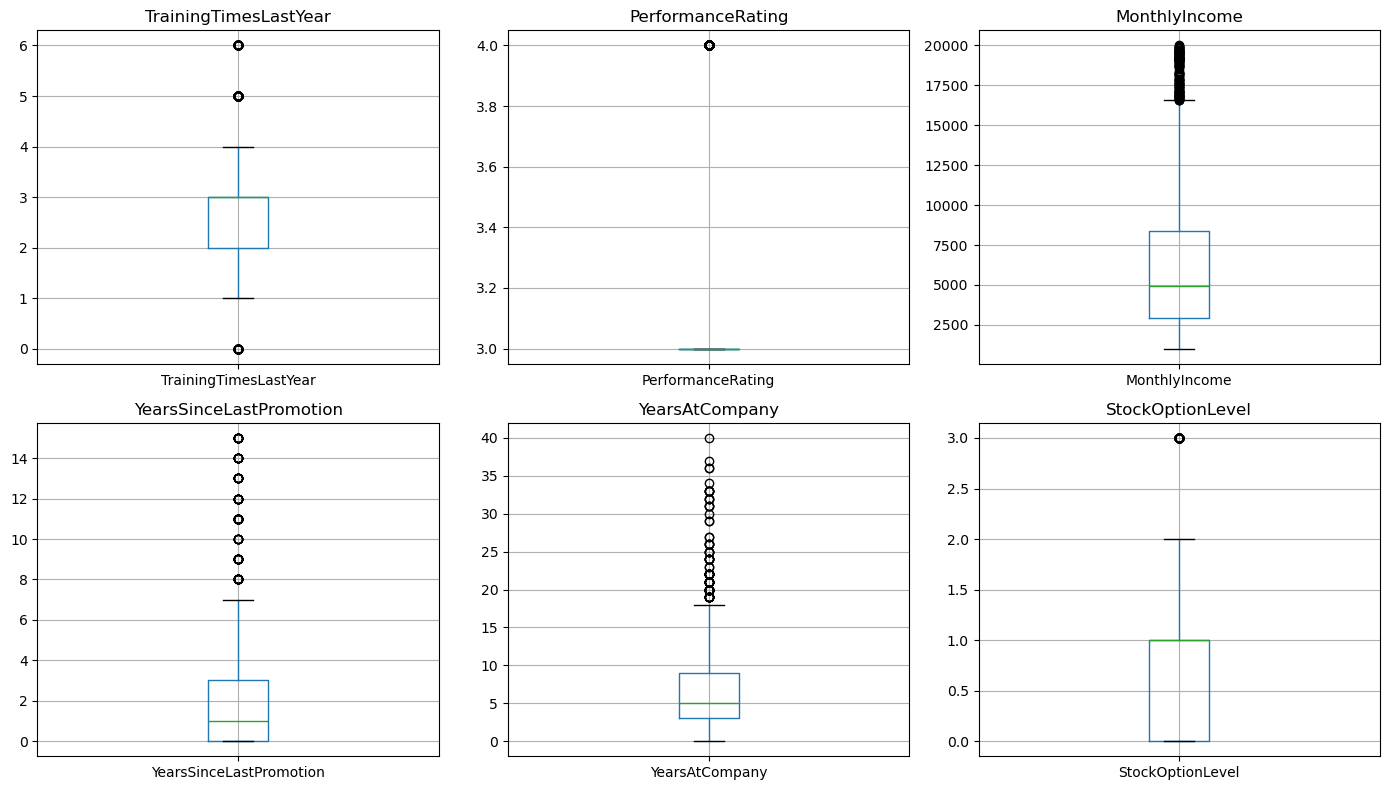

In [ ]:
# Método gráfico: boxplots de las variables con más valores atípicos IQR
columnas_a_graficar = resumen_outliers_iqr.head(6)["columna"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), columnas_a_graficar):
    df_hr.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("boxplots_outliers.png", dpi=120)
plt.show()

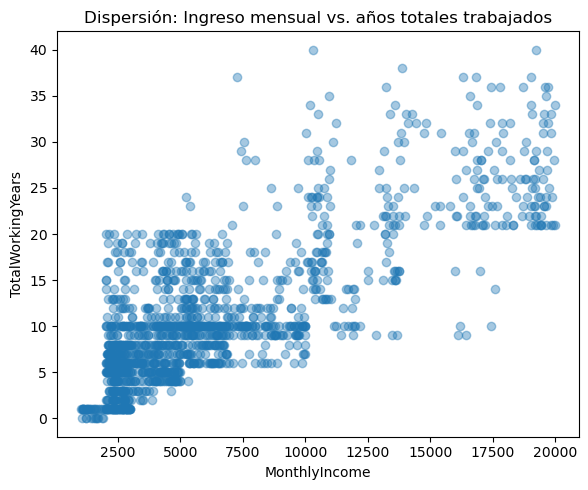

In [39]:
# Método gráfico: dispersión entre dos variables clave
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_hr["MonthlyIncome"], df_hr["TotalWorkingYears"], alpha=0.4)
ax.set_xlabel("MonthlyIncome")
ax.set_ylabel("TotalWorkingYears")
ax.set_title("Dispersión: Ingreso mensual vs. años totales trabajados")
plt.tight_layout()
plt.savefig("dispersion_income_vs_years.png", dpi=120)
plt.show()